# IMPORTING LIBRARIES

In [ ]:
!pip install pandas torch transformers tqdm matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import ast
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Configure tqdm for pandas integration
tqdm.pandas()

In [ ]:
# Set the device to use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Load the pre-trained FinBERT model and tokenizer
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE)

print("FinBERT model loaded successfully.")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

FinBERT model loaded successfully.


In [ ]:
try:
    df = pd.read_csv('BTC.csv')
    df['date'] = pd.to_datetime(df['begins_at']).dt.date
    print("Dataset loaded.")
except FileNotFoundError:
    print("Error: 'BTC.csv' not found. Please make sure the file is in the same directory.")

# Safely evaluate the string representation of the list in the 'articles' column
df['articles'] = df['articles'].apply(ast.literal_eval)

# Explode the DataFrame to have one row per article, keeping the date and price info
articles_df = df.explode('articles').rename(columns={'articles': 'headline'})

# Remove any rows that might have non-string headlines after exploding
articles_df = articles_df[articles_df['headline'].apply(isinstance, args=(str,))].copy()

print(f"Found {len(articles_df)} total headlines to analyze.")
articles_df.head()

Dataset loaded.
Found 17964 total headlines to analyze.


,Unnamed: 0,begins_at,open_price,close_price,high_price,low_price,symbol,headline,date
0,0,2018-02-25,9680.2,9584.45,9864.64,9300.02,BTC,Original Pizza Day Purchaser Does It Again Wit...,2018-02-25
0,0,2018-02-25,9680.2,9584.45,9864.64,9300.02,BTC,This 11-year-old just wrote a book on bitcoin ...,2018-02-25
0,0,2018-02-25,9680.2,9584.45,9864.64,9300.02,BTC,"Without Mentioning Blockchain, Putin Says That...",2018-02-25
0,0,2018-02-25,9680.2,9584.45,9864.64,9300.02,BTC,El comprador original del Pizza Day lo hace de...,2018-02-25
0,0,2018-02-25,9680.2,9584.45,9864.64,9300.02,BTC,Meet the strippers tattooed with BARCODES so s...,2018-02-25


In [ ]:
# We'll process in batches to be more efficient
batch_size = 32
results = []

print("Performing sentiment analysis... (This may take a while)")

# Use tqdm for a progress bar
for i in tqdm(range(0, len(articles_df), batch_size), desc="Analyzing Headlines"):
    batch_headlines = articles_df['headline'].iloc[i:i+batch_size].tolist()

    # Tokenize the batch
    inputs = tokenizer(batch_headlines, padding=True, truncation=True, return_tensors="pt", max_length=512).to(DEVICE)

    # Get model outputs (logits)
    with torch.no_grad(): # No need to calculate gradients for inference
        outputs = model(**inputs)

    # Convert logits to probabilities using softmax
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

    # The model's labels are: 0: positive, 1: negative, 2: neutral
    results.extend(predictions.cpu().numpy())

# Create a DataFrame with the sentiment scores
sentiment_df = pd.DataFrame(results, columns=['positive', 'negative', 'neutral'])

# Combine the sentiment scores with the articles DataFrame
# We reset the index on both to ensure proper alignment
articles_df.reset_index(drop=True, inplace=True)
sentiment_df.reset_index(drop=True, inplace=True)
df_with_sentiment = pd.concat([articles_df, sentiment_df], axis=1)

print("\nAnalysis complete.")
df_with_sentiment[['date', 'headline', 'positive', 'negative', 'neutral']].head()

Performing sentiment analysis... (This may take a while)


Analyzing Headlines:   0%|          | 0/562 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



Analysis complete.


,date,headline,positive,negative,neutral
0,2018-02-25,Original Pizza Day Purchaser Does It Again Wit...,0.039238,0.020659,0.940103
1,2018-02-25,This 11-year-old just wrote a book on bitcoin ...,0.087572,0.014891,0.897537
2,2018-02-25,"Without Mentioning Blockchain, Putin Says That...",0.239135,0.012883,0.747982
3,2018-02-25,El comprador original del Pizza Day lo hace de...,0.186265,0.020018,0.793717
4,2018-02-25,Meet the strippers tattooed with BARCODES so s...,0.050225,0.023954,0.925821


In [ ]:
# Calculate a single sentiment score: (positive - negative)
df_with_sentiment['sentiment_score'] = df_with_sentiment['positive'] - df_with_sentiment['negative']

# Group by date and calculate the average sentiment score
daily_sentiment = df_with_sentiment.groupby('date')['sentiment_score'].mean().reset_index()

# Merge the daily sentiment back with the original price data
df['date'] = pd.to_datetime(df['date'])
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])
final_df = pd.merge(df, daily_sentiment, on='date', how='left')

# Save the final results
output_filename = 'BTC_with_FinBERT_sentiment.csv'
final_df.to_csv(output_filename, index=False)

print(f"Results saved to '{output_filename}'")
final_df.head()

Results saved to 'BTC_with_FinBERT_sentiment.csv'


,Unnamed: 0,begins_at,open_price,close_price,high_price,low_price,symbol,articles,date,sentiment_score
0,0,2018-02-25,9680.200,9584.450,9864.640,9300.02,BTC,[Original Pizza Day Purchaser Does It Again Wi...,2018-02-25,0.100231
1,1,2018-02-26,9592.495,10318.785,10452.515,9378.91,BTC,[Bitcoin Pizza Day 2: How A Lightning Payment ...,2018-02-26,-0.257475
2,2,2018-02-27,10318.785,10548.385,10861.010,10140.93,BTC,"[Rapper 50 Cent, Who Bragged About Owning Bitc...",2018-02-27,-0.115190
3,3,2018-02-28,10552.470,10314.965,11058.680,10271.26,BTC,"[This Is Who Controls Bitcoin, British Man in ...",2018-02-28,-0.111687
4,4,2018-03-01,10314.965,10950.900,11087.430,10226.54,BTC,[Bitcoin makes inroads in LA’s residential rea...,2018-03-01,-0.331546


Visualization saved to 'BTC_Price_vs_Sentiment.png'


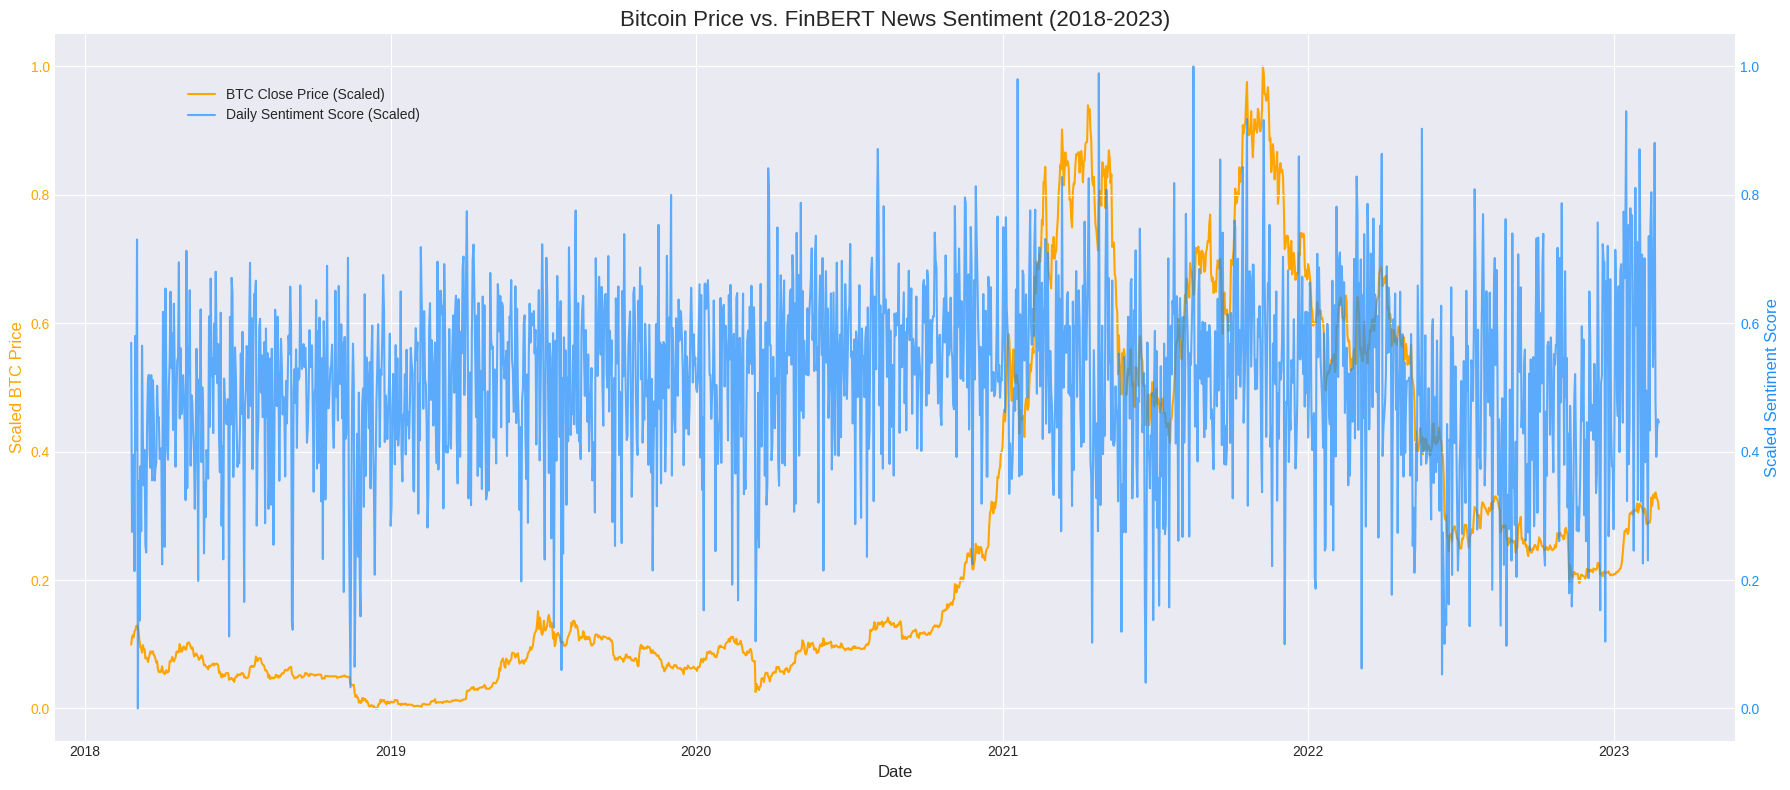

In [ ]:
# Prepare data for plotting by setting the date as the index
plot_df = final_df.sort_values('date').set_index('date')

# Scale both price and sentiment to be between 0 and 1 for better comparison
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(plot_df[['close_price', 'sentiment_score']].fillna(0))
scaled_df = pd.DataFrame(scaled_data, columns=['close_price', 'sentiment_score'], index=plot_df.index)

# Create the plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot Bitcoin's closing price on the primary y-axis
ax1.plot(scaled_df.index, scaled_df['close_price'], color='orange', label='BTC Close Price (Scaled)')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Scaled BTC Price', color='orange', fontsize=12)
ax1.tick_params(axis='y', labelcolor='orange')

# Create a second y-axis for the sentiment score
ax2 = ax1.twinx()
ax2.plot(scaled_df.index, scaled_df['sentiment_score'], color='dodgerblue', alpha=0.7, label='Daily Sentiment Score (Scaled)')
ax2.set_ylabel('Scaled Sentiment Score', color='dodgerblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='dodgerblue')

# Final touches
plt.title('Bitcoin Price vs. FinBERT News Sentiment (2018-2023)', fontsize=16)
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))

# Save the plot to a file
plot_filename = 'BTC_Price_vs_Sentiment.png'
plt.savefig(plot_filename)
print(f"Visualization saved to '{plot_filename}'")

# Display the plot
plt.show()